In [1]:
import matplotlib.pyplot as plt
import numpy as np
import graphical_sampling as gs
import pandas as pd
from tqdm import tqdm

from graphical_sampling import Population

In [49]:
N = 1000
n = 16
coords = np.loadtxt('populations/RegularPop1000_2d.csv', delimiter=",", skiprows=0)
rng = gs.random.rng()
probs = rng.equal_inclusions(n, N)
num_zones = (3, 3)
pop = gs.Population(coords, probs, n=n)

<Axes: title={'center': 'FIP Balanced 16-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

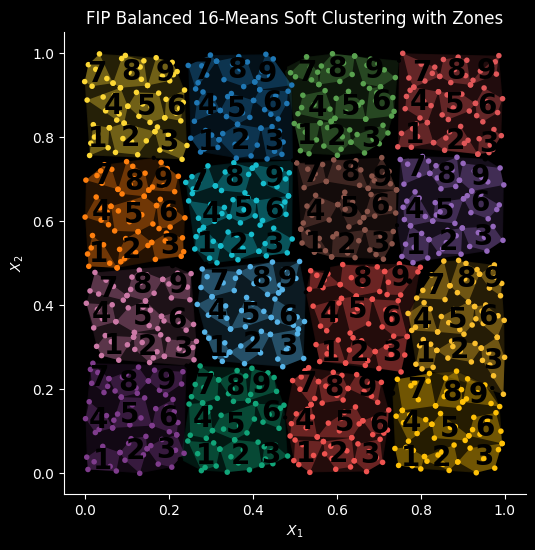

In [50]:
init_centroids = rng.grid_coords((4, 4))
ipb = gs.clustering.IPBalancedOTNMeans(n)
ipb.fit(pop, init_centroids)
ipb.fit_zones(num_zones=num_zones, mode='sweep_yx')
design = gs.Design.from_order(
    pop,
    order=gs.Order.from_clusters(pop, ipb.clusters, None, None, 1)
)
ipb.plot(mode='soft')

In [51]:
zones_centroids = []
for cluster in design.order.clusters:
    for zone in cluster.zones:
        zones_centroids.append(pop.coords[zone.indices].mean(axis=0))

def select(m, indices):
    selected = []
    j = 0
    for i in indices:
        selected.append(zones_centroids[i+j-1])
        j += m
    return np.array(selected)

def cal_moran(pop, points):
    new_coords = pop.coords.tolist()
    new_coords.extend(points.tolist())
    new_coords = np.array(new_coords)
    new_probs = rng.equal_inclusions(pop.n, new_coords.shape[0])
    new_pop = gs.Population(new_coords, new_probs, n=pop.n)
    moran = gs.index.Moran(new_pop)
    return moran.score(np.arange(pop.N, new_pop.N).reshape(1, -1))

[-0.31371057]


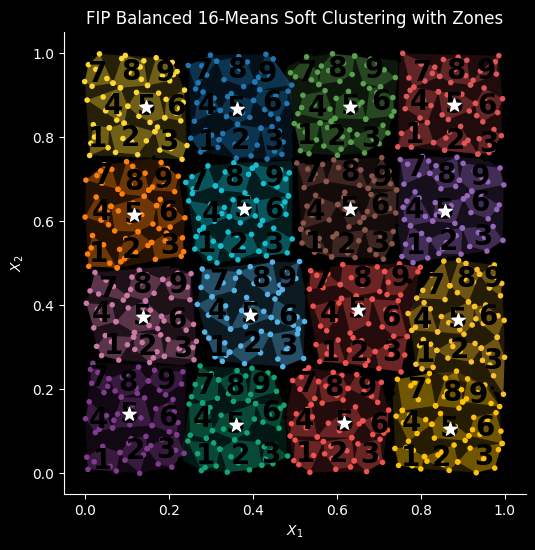

In [53]:
# sorting = [8, 5, 2, 1, 0, 3, 4, 7, 6]
       #   0  1  2  3  4  5  6  7  8

indices = [5]*16

points = select(num_zones[0]*num_zones[1], np.array(indices))
ax = ipb.plot(mode='soft')
ax.scatter(*points.T, color='white', marker='*', s=100, zorder=10)
print(cal_moran(pop, points))